In [117]:
import pandas as pd
import numpy as np

In [118]:
df = pd.read_csv('customer_churn.csv')
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null    str  
 6   PaperlessBilling  500 non-null    str  
 7   SeniorCitizen     500 non-null    int64
 8   Churn             500 non-null    int64
dtypes: int64(5), str(4)
memory usage: 50.8 KB


"CustomerID","PaperlessBilling","PaymentMethod","Contract" are categorical data columns.

In [120]:
df1= df.copy(deep=True)

#### Distribution of churn vs non churn

In [121]:
# Print the raw counts (How many 0s and 1s)
print("--- Raw Counts ---")
print(df['Churn'].value_counts())

# Print percentages
print("\n--- Percentages ---")
print(df['Churn'].value_counts(normalize=True) * 100)

--- Raw Counts ---
Churn
0    447
1     53
Name: count, dtype: int64

--- Percentages ---
Churn
0    89.4
1    10.6
Name: proportion, dtype: float64


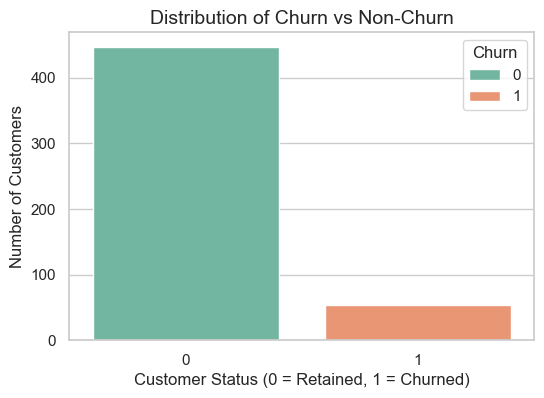

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2', hue= df['Churn'])
plt.title('Distribution of Churn vs Non-Churn', fontsize=14)
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

#### Data transformation

In [123]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['en_PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])

# verify the transformation
df[['en_PaperlessBilling', 'PaperlessBilling']].head()

,en_PaperlessBilling,PaperlessBilling
0,0,No
1,1,Yes
2,0,No
3,0,No
4,0,No


In [124]:
df['Contract'].value_counts()

Contract
One year          186
Month-to-month    170
Two year          144
Name: count, dtype: int64

In [125]:
from sklearn.preprocessing import OrdinalEncoder
contract_order = [['Month-to-month','One year','Two year']]
oe = OrdinalEncoder(categories=contract_order)
df['en_contract'] = oe.fit_transform(df[['Contract']])

#verify transform
df[['Contract','en_contract']].head()

,Contract,en_contract
0,One year,1.0
1,Month-to-month,0.0
2,Two year,2.0
3,Month-to-month,0.0
4,One year,1.0


In [126]:
df['en_contract']=df['en_contract'].astype(int)

In [127]:
df['PaymentMethod'].value_counts()

PaymentMethod
Credit Card         178
Electronic Check    163
Bank Transfer       159
Name: count, dtype: int64

In [128]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first') 
payment_encoded = ohe.fit_transform(df[['PaymentMethod']])
payment_df = pd.DataFrame(payment_encoded, columns=ohe.get_feature_names_out(['PaymentMethod']))
df = pd.concat([df, payment_df], axis=1)
print(df.columns)

Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn',
       'en_PaperlessBilling', 'en_contract', 'PaymentMethod_Credit Card',
       'PaymentMethod_Electronic Check'],
      dtype='str')


#### Feature Scaling

In [129]:
from sklearn.preprocessing import StandardScaler
scaler_std = StandardScaler()
num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']
df_standardized = df.copy(deep=True)
df_standardized[num_cols] = scaler_std.fit_transform(df[num_cols])
print("--- Standard Scaled Data ---")
print(df_standardized[num_cols].describe().round(2))

--- Standard Scaled Data ---
       Tenure  MonthlyCharges  TotalCharges
count  500.00          500.00        500.00
mean     0.00            0.00          0.00
std      1.00            1.00          1.00
min     -1.72           -1.81         -1.81
25%     -0.85           -0.90         -0.89
50%      0.02            0.03         -0.02
75%      0.85            0.86          0.90
max      1.67            1.65          1.66


In [130]:
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler()
df_normalized = df.copy(deep=True)
df_normalized[num_cols] = scaler_minmax.fit_transform(df[num_cols])
print("\n--- Min-Max Scaled Data ---")
print(df_normalized[num_cols].describe().round(2))


--- Min-Max Scaled Data ---
       Tenure  MonthlyCharges  TotalCharges
count  500.00          500.00        500.00
mean     0.51            0.52          0.52
std      0.30            0.29          0.29
min      0.00            0.00          0.00
25%      0.26            0.26          0.27
50%      0.51            0.53          0.51
75%      0.76            0.77          0.78
max      1.00            1.00          1.00
